In [22]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Dataset medical

1.1. Dataset si DataLoader

In [23]:
# Definim un Dataset custom; pentru tema voastra imaginile pot fi
# fete (face recognition) sau mole-uri (skin lesion classification).
class ImageFolderDataset(Dataset):

    def __init__(self, img_dir, csv_file, transform = None):
        self.samples = []
        self.transform = transform
        df = pd.read_csv(csv_file, sep=",")
        for index, row in df.iterrows():
            img_name = str(row["path"])
            original_label = int(row["label"])
            pytorch_label = original_label - 1
            path = os.path.join(img_dir, img_name)
            self.samples.append((path, pytorch_label))

    def __len__(self):
        # PyTorch are nevoie sa stie cate exemple sunt in dataset
        return len(self.samples)

    def __getitem__(self, idx):
        # Incarcam imaginea si eticheta pentru indexul cerut
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")  # ne asiguram ca avem 3 canale

        if self.transform is not None:
            # Aplicam transformarile (resize, normalizare, augmentari, etc.)
            img = self.transform(img)

        return img, label

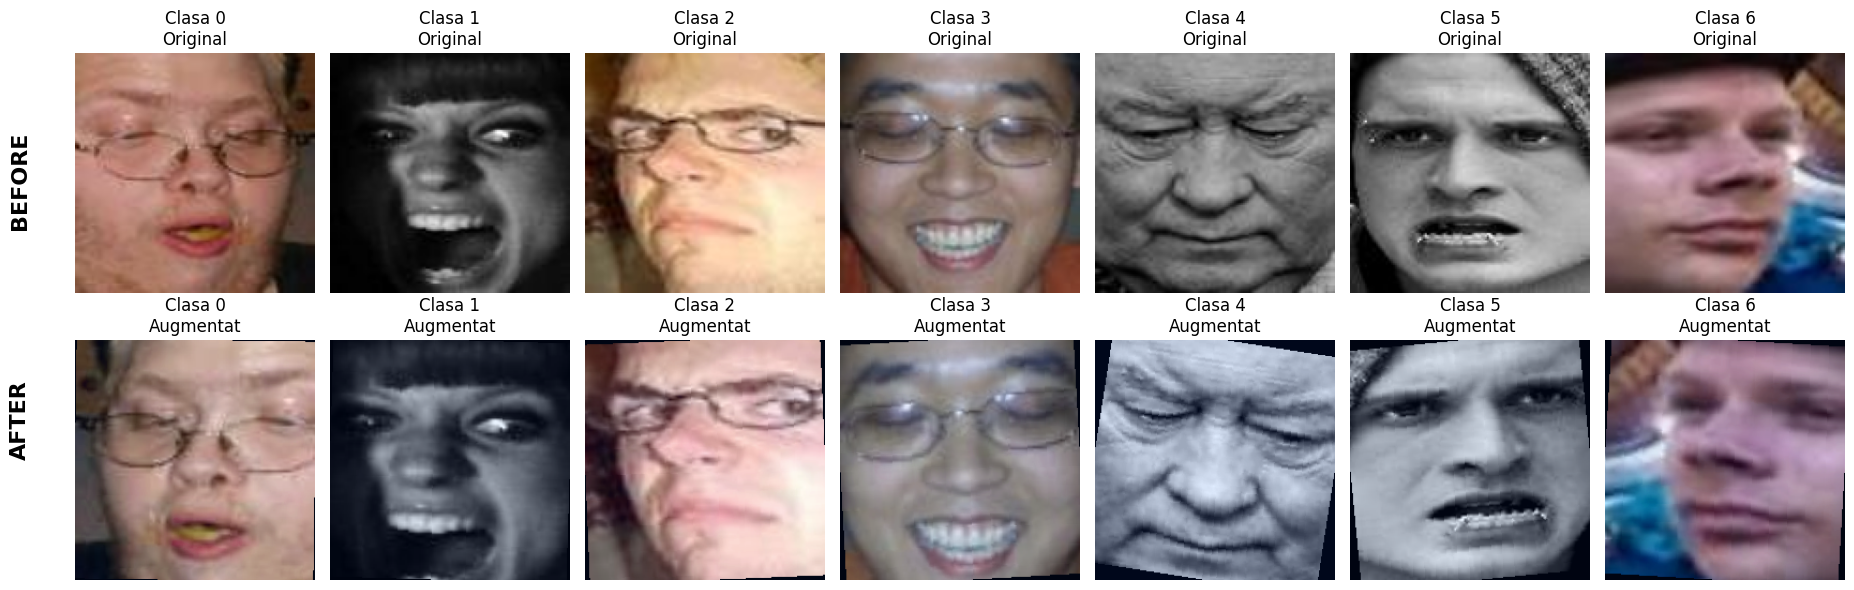

Graficul comparativ a fost salvat cu succes ca 'expresii_before_after_ResNet-18 fara warmup.png'!


In [25]:
from torchvision import transforms
from torch.utils.data import ConcatDataset, DataLoader
# Transformari minimale: resize la o dimensiune fixa, conversie in tensor si normalizare.
# Pe imaginile de tema (rezolutie mica) folositi o dimensiune apropiata de cea originala.
train_transform = transforms.Compose([
transforms.Resize((256, 256)), # uniformizam dimensiunea
transforms.RandomCrop(224),
transforms.RandomHorizontalFlip(),
transforms.RandomRotation(degrees=10),
transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.2, hue=0.04),
#transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5)),
#transforms.RandomGrayscale(p=0.01),
transforms.ToTensor(), # PIL -> Tensor cu valori in [0, 1]
#transforms.Normalize(mean = [0.5752126091262171,  0.4497227663589234, 0.4012869135370431] , std = [0.26532880449272844, 0.24229550144470252, 0.24068486736909714]), # normalizare simpla in [-1, 1]
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224), 
    transforms.ToTensor(), 
    #transforms.Normalize(mean = [0.5752126091262171,  0.4497227663589234, 0.4012869135370431] , std = [0.26532880449272844, 0.24229550144470252, 0.24068486736909714]),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
df_kaggle = pd.read_csv("you-re-on-candid-camera/splits/remote_test.csv")
df_kaggle = df_kaggle.rename(columns={'id': 'path'})
df_kaggle['label'] = 1 
df_kaggle.to_csv("you-re-on-candid-camera/splits/remote_test_formatat.csv", index=False)
train_set = ImageFolderDataset("you-re-on-candid-camera", "you-re-on-candid-camera/splits/train.csv", transform=train_transform)
test_set = ImageFolderDataset("you-re-on-candid-camera", "you-re-on-candid-camera/splits/local_test.csv", transform=val_transform)
#train_set = ConcatDataset([train_set_orig, test_set_orig])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
#test_set_kaggle = ImageFolderDataset("you-re-on-candid-camera", "you-re-on-candid-camera/splits/remote_test_formatat.csv", transform=val_transform)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

def salveaza_vizualizare_augmentare(dataset, transform_augmentare, numele_salvarii="vizualizare_augmentare.png"):
    imagini_clase = {}
    for path, label in dataset.samples:
        if label not in imagini_clase:
            img_pil = Image.open(path).convert("RGB")
            imagini_clase[label] = img_pil
        
        if len(imagini_clase) == 7:
            break

    clase_sortate = sorted(imagini_clase.keys())

    fig, axes = plt.subplots(2, 7, figsize=(20, 6))

    for i, clasa in enumerate(clase_sortate):
        img_originala = imagini_clase[clasa]
        img_before = img_originala.resize((128, 128))
        img_after_tensor = transform_augmentare(img_originala)
        
        img_after = img_after_tensor.permute(1, 2, 0).numpy()
        img_after = (img_after - img_after.min()) / (img_after.max() - img_after.min())

        axes[0, i].imshow(img_before)
        axes[0, i].set_title(f"Clasa {clasa}\nOriginal")
        axes[0, i].axis("off")

        axes[1, i].imshow(img_after)
        axes[1, i].set_title(f"Clasa {clasa}\nAugmentat")
        axes[1, i].axis("off")

    fig.text(0.08, 0.7, "BEFORE", va="center", ha="center", rotation="vertical", fontsize=16, fontweight="bold")
    fig.text(0.08, 0.3, "AFTER", va="center", ha="center", rotation="vertical", fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0.1, 0, 1, 1])
    
    plt.savefig(numele_salvarii, dpi=300)
    plt.show()
    print(f"Graficul comparativ a fost salvat cu succes ca '{numele_salvarii}'!")

salveaza_vizualizare_augmentare(train_set, train_transform, numele_salvarii="expresii_before_after_ResNet-18 fara warmup.png")

1.2. Model, functie de loss, optimizator

In [11]:
import torch.nn as nn
import torch.optim as optim
# Exemplu de MLP simplu pentru imagini 128x128 RGB (3*128*128 = 49152 features de intrare)
class SimpleMLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*128*128, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3), # dropout pentru regularizare
            nn.Linear(512, num_classes), # iesirea = scoruri (logits) per clasa
        )
    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleMLP(num_classes=7).to(device)
# CrossEntropyLoss combina LogSoftmax + NLLLoss; primeste logits, NU probabilitati
labels = np.array([label for _, label in train_set.samples])
class_counts = np.bincount(labels) 
counts = torch.tensor(class_counts, dtype=torch.float)
weights = counts.sum() / (len(counts) * counts)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
# Adam este o alegere sigura pentru inceput; SGD+momentum poate fi mai bun cu tuning
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

1.3 Bucla de antrenare si evaluare

In [ ]:
import matplotlib.pyplot as plt


def train_one_epoch(model, loader, criterion, optimizer, device):
    # Setăm modelul pe modul "train"
    model.train()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 1) Resetăm gradientii
        optimizer.zero_grad()

        # 2) Forward pass
        logits = model(images)

        # 3) Loss
        loss = criterion(logits, labels)

        # 4) Backward pass
        loss.backward()

        # 5) Update parametri
        optimizer.step()

        # Statistici
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    # Modul eval
    model.eval()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


# ---------------------------
# TRAIN LOOP
# ---------------------------

num_epochs = 20

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "train_f1_macro": [], 
    "train_f1_micro": [], 
    "val_f1_macro": [], 
    "val_f1_micro": []
}

for epoch in range(num_epochs):
    tr_loss, tr_acc, tr_f1_macro, tr_f1_micro = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    va_loss, va_acc, va_f1_macro, va_f1_micro = evaluate(
        model, test_loader, criterion, device
    )

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["train_f1_macro"].append(tr_f1_macro)
    history["train_f1_micro"].append(tr_f1_micro)
    history["val_f1_macro"].append(va_f1_macro)
    history["val_f1_micro"].append(va_f1_micro)

    print(
        f"Epoca {epoch+1:02d} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.3f} f1_mac={tr_f1_macro:.3f}  f1_mic={tr_f1_mic:.3f}| "
        f"val loss={va_loss:.4f} acc={va_acc:.3f} f1_mac={va_f1_macro:.3f} f1_mic={va_f1_macro:.3f}"
    )

    # Salvare model (exemplu simplu)
    torch.save(model.state_dict(), "best_model.pt")



Epoca 01 | train loss=5.8764 acc=0.446 f1_mac=0.295 | val loss=2.2842 acc=0.520 f1_mac=0.321
Epoca 02 | train loss=1.9260 acc=0.521 f1_mac=0.357 | val loss=1.9818 acc=0.527 f1_mac=0.359
Epoca 03 | train loss=1.5126 acc=0.562 f1_mac=0.405 | val loss=1.6939 acc=0.542 f1_mac=0.394
Epoca 04 | train loss=1.4623 acc=0.570 f1_mac=0.429 | val loss=1.4699 acc=0.570 f1_mac=0.433
Epoca 05 | train loss=1.2779 acc=0.599 f1_mac=0.453 | val loss=1.3483 acc=0.597 f1_mac=0.436
Epoca 06 | train loss=1.2230 acc=0.610 f1_mac=0.480 | val loss=1.4704 acc=0.608 f1_mac=0.411
Epoca 07 | train loss=1.2670 acc=0.612 f1_mac=0.485 | val loss=1.6910 acc=0.560 f1_mac=0.373
Epoca 08 | train loss=1.3824 acc=0.602 f1_mac=0.471 | val loss=1.8357 acc=0.574 f1_mac=0.403
Epoca 09 | train loss=1.3698 acc=0.608 f1_mac=0.477 | val loss=1.5971 acc=0.599 f1_mac=0.428
Epoca 10 | train loss=1.2805 acc=0.619 f1_mac=0.496 | val loss=1.4922 acc=0.597 f1_mac=0.460
Epoca 11 | train loss=1.4577 acc=0.595 f1_mac=0.462 | val loss=1.9455 

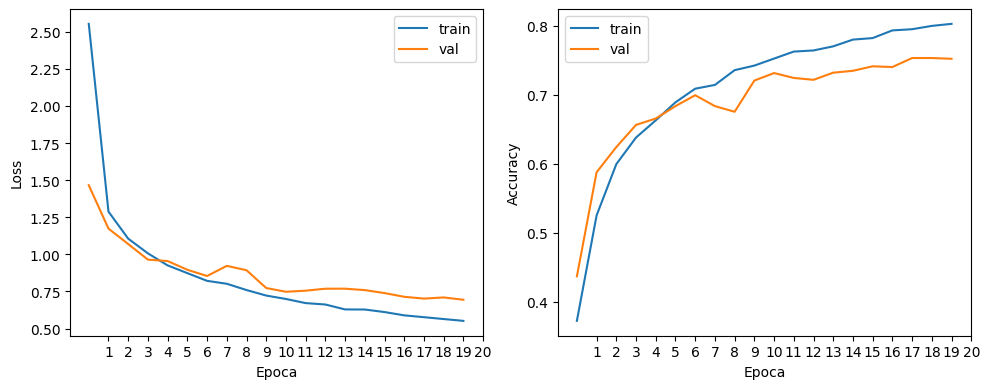

In [8]:
# ---------------------------
# PLOT RESULTS
# ---------------------------
epochs = list(range(1, num_epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].legend()
axes[0].set_xticks(epochs)
axes[1].set_xticks(epochs)

plt.tight_layout()
plt.savefig('MLP_simplu_expresii_cu dropout.png')
plt.show()

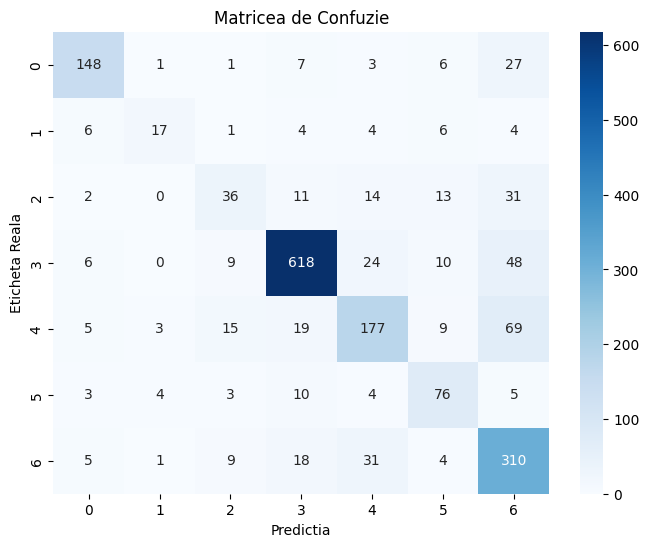

In [9]:
def plot_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # calculam matricea
    conf_matix = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matix, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Matricea de Confuzie')
    plt.ylabel('Eticheta Reala')
    plt.xlabel('Predictia')
    plt.savefig('MLP_simplu_expresii_cu dropout_matrice_confuzie.png')
    plt.show()

plot_confusion_matrix(model, test_loader, device, num_classes=7)

CNN

5.1 Adaugarea BatchNorm intr-un CNN simplu

In [4]:
import torch.nn as nn
# Pattern-ul standard intr-un CNN modern: Conv -> BatchNorm -> Activare -> (eventual Pool)
# IMPORTANT: bias=False la Conv2d cand este urmat de BatchNorm,
# pentru ca BN are deja propriul "beta" care joaca rolul de bias.
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), # cate un set de (gamma, beta) per canal
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 64x64 -> 32x32
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 32x32 -> 16x16
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            #nn.AdaptiveAvgPool2d(1), # global average pooling -> (B, 128, 1, 1)
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),     
            nn.Linear(32768, 512),     
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1) # (B, 128, 1, 1) -> (B, 128)
        return self.classifier(x)

5.2 Cum se comporta BatchNorm la train vs eval


In [5]:
import torch.optim as optim
import numpy as np
# BatchNorm are DOUA moduri de functionare, controlate de model.train() / model.eval():
#
# - In modul "train": foloseste media si varianta calculate pe BATCH-UL CURENT.
# In paralel, actualizeaza niste statistici "running" (running_mean, running_var)
# printr-o medie mobila exponentiala.
#
# - In modul "eval": foloseste running_mean / running_var (statistici "inghetate"),
# NU statisticile batch-ului curent. Acest lucru este esential pentru ca predictia
# sa fie deterministica si sa nu depinda de ce alte exemple sunt in batch.
#
# Exact din acest motiv este OBLIGATORIU sa apelati model.eval() inainte de validare/inferenta -
# altfel performanta poate parea ciudat de slaba sau de instabila.
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleCNN(num_classes=7).to(device)
labels = np.array([label for _, label in train_set.samples])
class_counts = np.bincount(labels) 
counts = torch.tensor(class_counts, dtype=torch.float)
weights = counts.sum() / (len(counts) * counts)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)


5.3 Interactiunea cu dimensiunea batch-ului

In [6]:
# BatchNorm estimeaza media si varianta DIN BATCH. Daca batch-ul este foarte mic
# (ex: batch_size=2 sau batch_size=4), aceste estimari devin zgomotoase si BN
# poate INRAUTATI antrenarea in loc sa o ajute.
#
# Reguli empirice:
# - batch_size >= 32 -> BatchNorm functioneaza foarte bine
# - batch_size < 16 -> luati in considerare alternative: GroupNorm sau LayerNorm
#
# Exemplu de inlocuire BN -> GroupNorm cand suntem fortati la batch-uri mici
# (ex: imagini mari care nu incap in VRAM):
# nn.GroupNorm(num_groups=8, num_channels=64) # 64 canale impartite in 8 grupuri
#
# ATENTIE: BatchNorm necesita batch_size > 1 ca sa poata calcula varianta.
# Daca ultimul batch are dimensiunea 1, antrenarea va da eroare.
# Solutie: drop_last=True in DataLoader.
train_loader = DataLoader(train_set, batch_size=64, shuffle=True,num_workers=2, drop_last=True)

In [7]:
import matplotlib.pyplot as plt


def train_one_epoch(model, loader, criterion, optimizer, device):
    # Setăm modelul pe modul "train"
    model.train()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 1) Resetăm gradientii
        optimizer.zero_grad()

        # 2) Forward pass
        logits = model(images)

        # 3) Loss
        loss = criterion(logits, labels)

        # 4) Backward pass
        loss.backward()

        # 5) Update parametri
        optimizer.step()

        # Statistici
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    # Modul eval
    model.eval()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


# ---------------------------
# TRAIN LOOP
# ---------------------------

num_epochs = 40

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "train_f1_macro": [], 
    "train_f1_micro": [], 
    "val_f1_macro": [], 
    "val_f1_micro": []
}

for epoch in range(num_epochs):
    tr_loss, tr_acc, tr_f1_macro, tr_f1_micro = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    va_loss, va_acc, va_f1_macro, va_f1_micro = evaluate(
        model, test_loader, criterion, device
    )

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["train_f1_macro"].append(tr_f1_macro)
    history["train_f1_micro"].append(tr_f1_micro)
    history["val_f1_macro"].append(va_f1_macro)
    history["val_f1_micro"].append(va_f1_micro)

    print(
        f"Epoca {epoch+1:02d} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.3f} f1_mic={tr_f1_micro:.3f} f1_mac={tr_f1_macro:.3f} | "
        f"val loss={va_loss:.4f} acc={va_acc:.3f} f1_mic={va_f1_micro:.3f} f1_mac={va_f1_macro:.3f} "
    )

    # Salvare model (exemplu simplu)
    torch.save(model.state_dict(), "best_model.pt")
    scheduler.step()


Epoca 01 | train loss=1.8304 acc=0.307 f1_mic=0.307 f1_mac=0.246 | val loss=1.4771 acc=0.506 f1_mic=0.506 f1_mac=0.398 
Epoca 02 | train loss=1.4889 acc=0.497 f1_mic=0.497 f1_mac=0.406 | val loss=1.2393 acc=0.545 f1_mic=0.545 f1_mac=0.465 
Epoca 03 | train loss=1.3084 acc=0.563 f1_mic=0.563 f1_mac=0.472 | val loss=1.2265 acc=0.568 f1_mic=0.568 f1_mac=0.476 
Epoca 04 | train loss=1.2213 acc=0.589 f1_mic=0.589 f1_mac=0.502 | val loss=1.1727 acc=0.579 f1_mic=0.579 f1_mac=0.484 
Epoca 05 | train loss=1.1259 acc=0.623 f1_mic=0.623 f1_mac=0.535 | val loss=1.1470 acc=0.590 f1_mic=0.590 f1_mac=0.513 
Epoca 06 | train loss=1.0659 acc=0.647 f1_mic=0.647 f1_mac=0.567 | val loss=0.9822 acc=0.659 f1_mic=0.659 f1_mac=0.577 
Epoca 07 | train loss=1.0090 acc=0.658 f1_mic=0.658 f1_mac=0.584 | val loss=1.0014 acc=0.648 f1_mic=0.648 f1_mac=0.534 
Epoca 08 | train loss=0.9563 acc=0.678 f1_mic=0.678 f1_mac=0.603 | val loss=1.0621 acc=0.629 f1_mic=0.629 f1_mac=0.526 
Epoca 09 | train loss=0.9294 acc=0.682 f

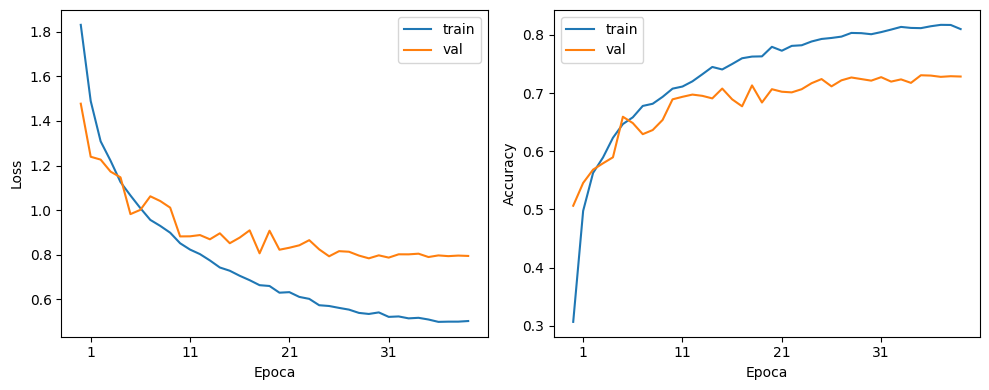

In [9]:
# ---------------------------
# PLOT RESULTS
# ---------------------------
epochs = list(range(1, num_epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].legend()
axes[0].set_xticks(epochs)
axes[1].set_xticks(epochs)

axes[0].set_xticks(range(1, num_epochs + 1, 10))
axes[1].set_xticks(range(1, num_epochs + 1, 10))

plt.tight_layout()
plt.savefig('CNN_simplu_expresii_cu BatchNorm, Dropout, fara adaptiveavgpool cu augmentari toate + Cross Entropy ponderat modif.png')
plt.show()

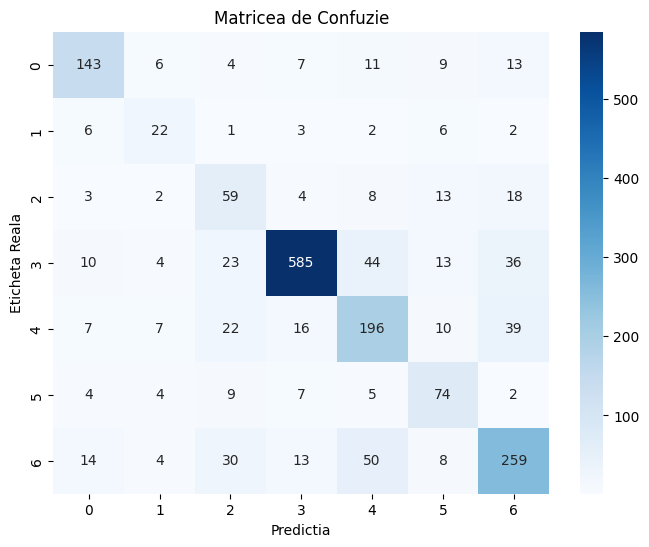

In [10]:
def plot_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # calculam matricea
    conf_matix = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matix, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Matricea de Confuzie')
    plt.ylabel('Eticheta Reala')
    plt.xlabel('Predictia')
    plt.savefig('CNN_simplu_expresii_cu BatchNorm, Dropout, fara adaptiveavgpool cu augmentari Cross Entropy ponderat toate_matrice_confuzie modif.png')
    plt.show()

plot_confusion_matrix(model, test_loader, device, num_classes=7)

In [11]:
import pathlib

class KaggleDataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.transform = transform
        self.df = pd.read_csv(csv_file)
        self.samples = []
        
        print("Scanăm folderul pentru a localiza imaginile... (poate dura câteva secunde)")
        # Mapăm instant toate fișierele .jpg din folderul proiectului (căutare recursivă)
        # Asta va găsi imaginea fie că e în train, test sau alt subfolder
        base_path = pathlib.Path(root_dir)
        all_images = {p.name: str(p) for p in base_path.rglob("*.jpg")}
        
        # Corelăm hărțile din CSV cu locațiile reale găsite pe disc
        for idx, row in self.df.iterrows():
            img_name = str(row['id']).split('/')[-1] # luăm doar numele curat, ex: test_0789_aligned.jpg
            
            if img_name in all_images:
                self.samples.append(all_images[img_name])
            else:
                # Dacă totuși lipsește ceva, să știm exact ce fișier e de vină
                raise FileNotFoundError(f"Imaginea {img_name} nu a fost găsită nicăieri în {root_dir}!")
        print(f"Succes! Am găsit toate cele {len(self.samples)} imagini pentru Kaggle.")
        
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        
        if self.transform is not None:
            img = self.transform(img)
            
        # Returnăm tensorul și numele de bază al imaginii pentru CSV-ul de Kaggle
        return img, pathlib.Path(img_path).name

In [12]:
def generate_kaggle_submission_faces_fixed(model, loader, device, output_file="submission_candid_camera_mlp.csv"):
    model.eval()
    image_ids = []
    predictions = []

    print("Generăm predicțiile pentru setul de fețe...")
    with torch.no_grad():
        for images, img_names in loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy() + 1
            
            image_ids.extend(img_names)
            predictions.extend(preds)

    # REPARARE: Schimbăm din 'Prediction' în 'label' ca să treacă de validarea Kaggle
    submission_df = pd.DataFrame({
        "Id": image_ids,
        "label": predictions  # <--- Fix-ul este aici!
    })
    
    submission_df.to_csv(output_file, index=False)
    print(f"Fișierul nou {output_file} a fost salvat! Încarcă-l pe acesta.")

# 1. Asigură-te că dataset-ul este instanțiat (din nou, dacă e nevoie)
kaggle_set = KaggleDataset(
    root_dir="you-re-on-candid-camera", 
    csv_file="you-re-on-candid-camera/splits/remote_test.csv",
    transform=val_transform
)

# 2. DEFINIREA propriu-zisă a loader-ului (Rulează celula asta!)
kaggle_loader = DataLoader(kaggle_set, batch_size=64, shuffle=False, num_workers=2)

# 3. Acum rulezi apelul care dădea eroare:
generate_kaggle_submission_faces_fixed(model, kaggle_loader, device, output_file="submission_candid_camera_mlp.csv")

Scanăm folderul pentru a localiza imaginile... (poate dura câteva secunde)
Succes! Am găsit toate cele 3068 imagini pentru Kaggle.
Generăm predicțiile pentru setul de fețe...
Fișierul nou submission_candid_camera_mlp.csv a fost salvat! Încarcă-l pe acesta.


ResNet-18

In [26]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer2.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True


num_ftrs = model.fc.in_features
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5), 
    nn.Linear(num_ftrs, 7)
)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

parametri = filter(lambda p: p.requires_grad, model.parameters())
labels_train = [label for _, label in train_set_orig.samples]
labels_test  = [label for _, label in test_set_orig.samples]
labels = np.array(labels_train + labels_test)
class_counts = np.bincount(labels) 
counts = torch.tensor(class_counts, dtype=torch.float)
weights = counts.sum() / (len(counts) * counts)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(parametri, lr=1e-4, weight_decay=1e-4)
warmup = LinearLR(optimizer, start_factor=0.1, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=35)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])


In [ ]:
import matplotlib.pyplot as plt
from torch.utils.data import Subset

def train_one_epoch(model, loader, criterion, optimizer, device):
    # Setăm modelul pe modul "train"
    model.train()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 1) Resetăm gradientii
        optimizer.zero_grad()

        # 2) Forward pass
        logits = model(images)

        # 3) Loss
        loss = criterion(logits, labels)

        # 4) Backward pass
        loss.backward()

        # 5) Update parametri
        optimizer.step()

        # Statistici
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro

@torch.no_grad()
def per_sample_losses(model, dataset, criterion_no_red, device, batch_size=128):
    model.eval()
    losses = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        # reduction="none" -> primim un loss per exemplu
        l = criterion_no_red(logits, labels)
        losses.append(l.cpu())
    return torch.cat(losses)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    # Modul eval
    model.eval()

    running_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    return running_loss / total, correct / total, f1_macro, f1_micro


# ---------------------------
# TRAIN LOOP
# ---------------------------

num_epochs = 25

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "train_f1_macro": [], 
    "train_f1_micro": [], 
    "val_f1_macro": [], 
    "val_f1_micro": []
}

criterion_no_red = nn.CrossEntropyLoss(reduction="none")

for epoch in range(num_epochs):
    losses = per_sample_losses(model, train_set, criterion_no_red, device)
    threshold = torch.quantile(losses, q=min(1.0, 0.3 + 0.05 * epoch))
    easy_idx = (losses <= threshold).nonzero(as_tuple=True)[0].tolist()
    subset = Subset(train_set, easy_idx)
    loader = DataLoader(subset, batch_size=64, shuffle=True)
    tr_loss, tr_acc, tr_f1_macro, tr_f1_micro = train_one_epoch(
        model, loader, criterion, optimizer, device
    )

    va_loss, va_acc, va_f1_macro, va_f1_micro = evaluate(
        model, test_loader, criterion, device
    )

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["train_f1_macro"].append(tr_f1_macro)
    history["train_f1_micro"].append(tr_f1_micro)
    history["val_f1_macro"].append(va_f1_macro)
    history["val_f1_micro"].append(va_f1_micro)

    print(
        f"Epoca {epoch+1:02d} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.3f} f1_mic={tr_f1_micro:.3f}  f1_mac={tr_f1_macro:.3f} | "
        f"val loss={va_loss:.4f} acc={va_acc:.3f}  f1_mic={va_f1_micro:.3f} f1_mac={va_f1_macro:.3f}"
    )

    # Salvare model (exemplu simplu)
    torch.save(model.state_dict(), "best_model.pt")
    scheduler.step()


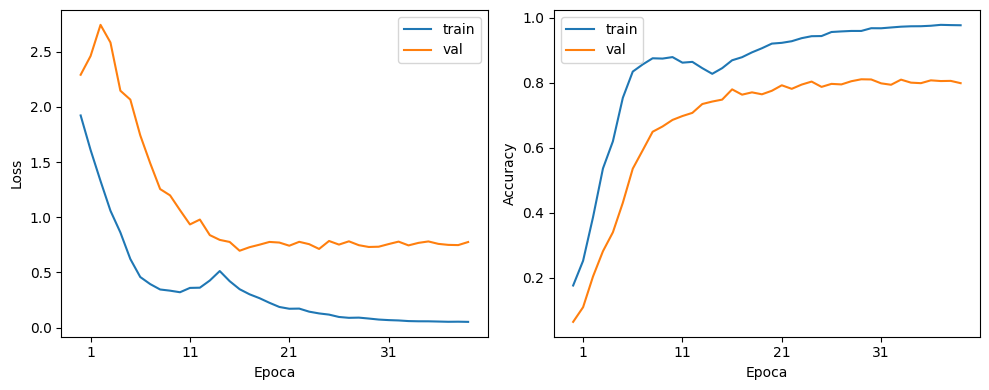

In [10]:
# ---------------------------
# PLOT RESULTS
# ---------------------------
epochs = list(range(1, num_epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_ylabel("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].legend()
axes[0].set_xticks(epochs)
axes[1].set_xticks(epochs)

axes[0].set_xticks(range(1, num_epochs + 1, 10))
axes[1].set_xticks(range(1, num_epochs + 1, 10))

plt.tight_layout()
plt.savefig('expresii_ResNet-18 cu warmup 3 layere dezghet curr learn.png')
plt.show()

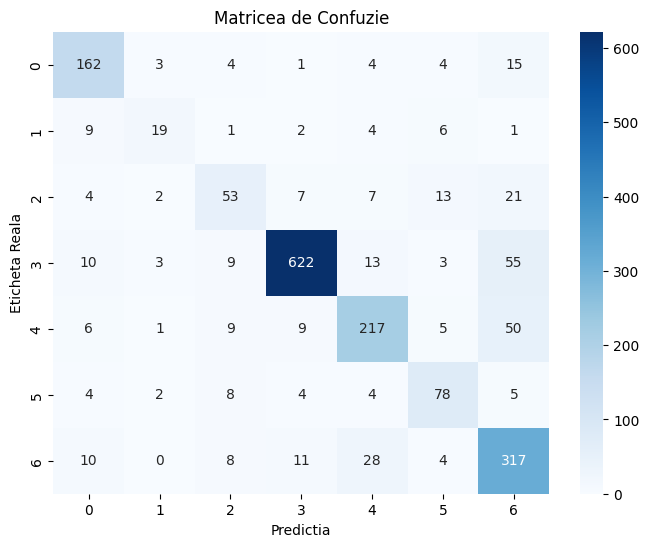

In [11]:
def plot_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # calculam matricea
    conf_matix = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matix, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Matricea de Confuzie')
    plt.ylabel('Eticheta Reala')
    plt.xlabel('Predictia')
    plt.savefig('expresii_ResNet-18 cu warmup 3 layere dezghet _matrice_confuzie curr lern.png')
    plt.show()

plot_confusion_matrix(model, test_loader, device, num_classes=7)

In [12]:
import pathlib

class KaggleDataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.transform = transform
        self.df = pd.read_csv(csv_file)
        self.samples = []
        
        print("Scanăm folderul pentru a localiza imaginile... (poate dura câteva secunde)")
        # Mapăm instant toate fișierele .jpg din folderul proiectului (căutare recursivă)
        # Asta va găsi imaginea fie că e în train, test sau alt subfolder
        base_path = pathlib.Path(root_dir)
        all_images = {p.name: str(p) for p in base_path.rglob("*.jpg")}
        
        # Corelăm hărțile din CSV cu locațiile reale găsite pe disc
        for idx, row in self.df.iterrows():
            img_name = str(row['id']).split('/')[-1] # luăm doar numele curat, ex: test_0789_aligned.jpg
            
            if img_name in all_images:
                self.samples.append(all_images[img_name])
            else:
                # Dacă totuși lipsește ceva, să știm exact ce fișier e de vină
                raise FileNotFoundError(f"Imaginea {img_name} nu a fost găsită nicăieri în {root_dir}!")
        print(f"Succes! Am găsit toate cele {len(self.samples)} imagini pentru Kaggle.")
        
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        
        if self.transform is not None:
            img = self.transform(img)
            
        # Returnăm tensorul și numele de bază al imaginii pentru CSV-ul de Kaggle
        return img, pathlib.Path(img_path).name

In [14]:
def generate_kaggle_submission_faces_fixed(model, loader, device, output_file="submission_candid_camera_mlp.csv"):
    model.eval()
    image_ids = []
    predictions = []

    print("Generăm predicțiile pentru setul de fețe...")
    with torch.no_grad():
        for images, img_names in loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy() + 1
            
            image_ids.extend(img_names)
            predictions.extend(preds)

    # REPARARE: Schimbăm din 'Prediction' în 'label' ca să treacă de validarea Kaggle
    submission_df = pd.DataFrame({
        "Id": image_ids,
        "label": predictions  # <--- Fix-ul este aici!
    })
    
    submission_df.to_csv(output_file, index=False)
    print(f"Fișierul nou {output_file} a fost salvat! Încarcă-l pe acesta.")

# 1. Asigură-te că dataset-ul este instanțiat (din nou, dacă e nevoie)
kaggle_set = KaggleDataset(
    root_dir="you-re-on-candid-camera", 
    csv_file="you-re-on-candid-camera/splits/remote_test.csv",
    transform=val_transform
)

# 2. DEFINIREA propriu-zisă a loader-ului (Rulează celula asta!)
kaggle_loader = DataLoader(kaggle_set, batch_size=64, shuffle=False, num_workers=2)

# 3. Acum rulezi apelul care dădea eroare:
generate_kaggle_submission_faces_fixed(model, kaggle_loader, device, output_file="submission_candid_camera_mlp.csv")

Scanăm folderul pentru a localiza imaginile... (poate dura câteva secunde)
Succes! Am găsit toate cele 3068 imagini pentru Kaggle.
Generăm predicțiile pentru setul de fețe...
Fișierul nou submission_candid_camera_mlp.csv a fost salvat! Încarcă-l pe acesta.


TensorBoard pentru vizualizarea eficienta

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import torchvision

# Numele rulei trebuie sa fie descriptiv; recomandare: include arhitectura + hiperparametrii cheie.
# In acest fel, cand deschideti TensorBoard veti putea distinge usor experimentele.
run_name = f"mlp_lr1e-3_bs64_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir=f"runs/{run_name}")

# Imagini: utile pentru a vedea cum arata batch-urile DUPA augmentari.
images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

# Varianta imbunatatita a buclei de antrenare care logheaza in TensorBoard
for epoch in range(num_epochs):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)
    
    # Scalars: o singura valoare per epoca, grupata logic prin "tag-ul" cu /
    # Astfel "Loss/train" si "Loss/val" vor aparea pe acelasi grafic in TensorBoard.
    writer.add_scalar("Loss/train", tr_loss, epoch)
    writer.add_scalar("Loss/val", va_loss, epoch)
    writer.add_scalar("Acc/train", tr_acc, epoch)
    writer.add_scalar("Acc/val", va_acc, epoch)
    
    # Logam si learning rate-ul (util cand folositi scheduler)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)
    
    # Histograme: utile pentru a vedea distributia ponderilor sau a gradientilor.
    for name, param in model.named_parameters():
        writer.add_histogram(f"weights/{name}", param, global_step=epoch)
        if param.grad is not None:
            writer.add_histogram(f"grads/{name}", param.grad, global_step=epoch)

# Hiperparametri: tab-ul HPARAMS permite compararea mai multor configuratii.
writer.add_hparams(
    {"lr": 1e-3, "batch_size": 64, "model": "MLP"},
    {"hparam/val_acc": va_acc, "hparam/val_loss": va_loss},
)

# important: inchidem writerul la final ca sa se scrie tot pe disc
writer.close()